In [50]:
# Метод опорных векторов (SVM - support vector machine) - классификация и регрессия
# Разделяющая классификация
# Выбирается линия с максимальным отступом

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

iris = sns.load_dataset("iris") 

species_int = []
for r in iris.values:
    match r[4]:
        case "setosa":
            species_int.append(1)
        case 'versicolor':
            species_int.append(2)
        case 'virginica':
            species_int.append(3)


species_int_df = pd.DataFrame(species_int)

In [10]:
data = iris[['sepal_length', 'petal_length', 'species']]
data_df = data[(data["species"] =="setosa") | (data["species"] == "versicolor")] 

[[4.8 1.9]
 [5.1 1.9]
 [5.1 3. ]]


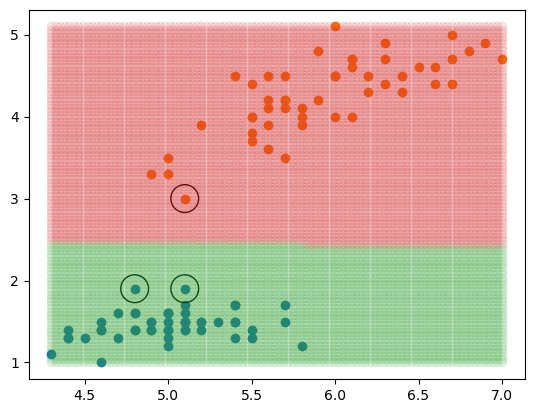

In [23]:
X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

data_df_seposa = data_df[data_df["species"] == "setosa"] 
data_df_versicolor = data_df[data_df["species"] == "versicolor"]

plt.scatter(data_df_seposa["sepal_length"], data_df_seposa["petal_length"]) 
plt.scatter(data_df_versicolor["sepal_length"], data_df_versicolor["petal_length"])

model = SVC(kernel='linear', C=10000)
model.fit(X, y)

print(model.support_vectors_)
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=400, facecolor='none', edgecolors='black')

x1_p = np.linspace (min(data_df["sepal_length"]), max(data_df["sepal_length"]), 100) 
x2_p = np.linspace (min(data_df["petal_length"]), max(data_df["petal_length"]), 100)

X1_p, X2_p = np.meshgrid(x1_p, x2_p)

X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=["sepal_length", "petal_length"])

y_p = model.predict(X_p)

X_p["species"] = y_p

X_p_setosa = X_p[X_p["species"] == "setosa"]
X_p_versicolor = X_p[X_p["species"] == "versicolor"]

plt.scatter(X_p_setosa["sepal_length"], X_p_setosa["petal_length"], alpha=0.1)
plt.scatter(X_p_versicolor["sepal_length"], X_p_versicolor["petal_length"], alpha=0.1)

plt.show()

In [51]:
# В случае, если данные перекрываются, то идеальной границы не существует. 
# У модели существует гиперпараметр, который определяет "размытие" отступа

data = iris[['sepal_length', 'petal_length', 'species']]

data_df = data[(data["species"] =="virginica") | (data["species"] == "versicolor")] 

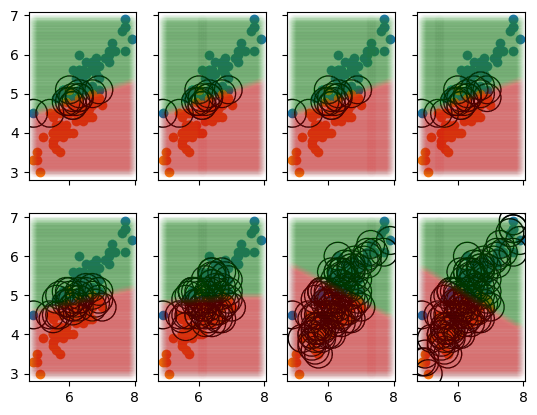

In [56]:
X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

data_df_virginica = data_df[data_df["species"] == "virginica"] 
data_df_versicolor = data_df[data_df["species"] == "versicolor"]

c_value = [[10000, 1000, 100, 10], [1, 0.1, 0.01, 0.001]]

fig, ax = plt.subplots(2, 4, sharex='col', sharey='row')

for i in range(2):
    for j in range(4):
        ax[i, j].scatter(data_df_virginica["sepal_length"], data_df_virginica["petal_length"]) 
        ax[i, j].scatter(data_df_versicolor["sepal_length"], data_df_versicolor["petal_length"])

        # Если С большое, то отступ задается "жестко", чем меньше С, тем отступ становится более "размытым"
        model = SVC(kernel='linear', C=c_value[i][j])
        model.fit(X, y)

        #print(model.support_vectors_)
        ax[i, j].scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=400, facecolor='none', edgecolors='black')

        x1_p = np.linspace (min(data_df["sepal_length"]), max(data_df["sepal_length"]), 100) 
        x2_p = np.linspace (min(data_df["petal_length"]), max(data_df["petal_length"]), 100)

        X1_p, X2_p = np.meshgrid(x1_p, x2_p)

        X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=["sepal_length", "petal_length"])

        
        y_p = model.predict(X_p)

        X_p["species"] = y_p

        X_p_virginica = X_p[X_p["species"] == "virginica"]
        X_p_versicolor = X_p[X_p["species"] == "versicolor"]

        ax[i, j].scatter(X_p_virginica["sepal_length"], X_p_virginica["petal_length"], alpha=0.01)
        ax[i, j].scatter(X_p_versicolor["sepal_length"], X_p_versicolor["petal_length"], alpha=0.01)


plt.show()

In [57]:
# Достоинства
# - Зависимость от небольшого числа опорных векторов => компактность модели
# - После обучения предсказания проходят очень быстро
# - На работу метода влияют ТОЛЬКО точки, находящиеся возле отступов, поэтому методы подходят для многомерных данных

# Недостатки
# - При большом количестве обучающих образцов могут быть значительные вычислительные затраты
# - Большая зависимость от размытости С. Поиск этого параметра может привести к большим вычислительным затратам
# - У результатов отсутствует вероятностная интерпретация

In [58]:
# Деревья решений и случайные леса
# СЛ - непараметрический алгоритм
# СЛ - пример ансамблевого метода, основанного на агрегации результатов множества простых моделей
# В реализациях дерева принятия решений в машиннои обучении вопросы обуычно ведут к разделению данных по осям, 
# т.е. каждый узел разбивает данные на две группы по одному из признаков

C:\Users\Polina\AppData\Local\Temp\ipykernel_15208\1293442120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['species'] = species_int_df


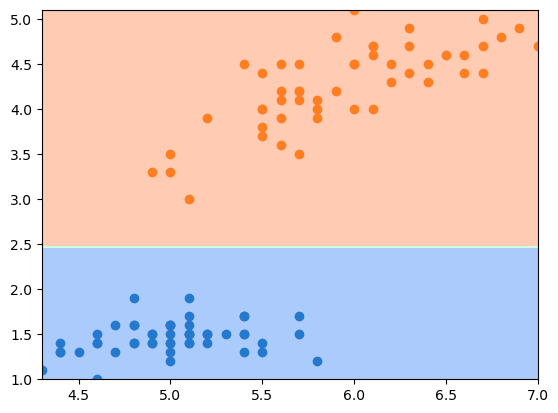

In [70]:
data = iris[['sepal_length', 'petal_length']]
data['species'] = species_int_df

data_df = data[(data["species"] == 1) | (data["species"] == 2)] 

X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

data_df_seposa = data_df[data_df["species"] == 1] 
data_df_versicolor = data_df[data_df["species"] == 2]

plt.scatter(data_df_seposa["sepal_length"], data_df_seposa["petal_length"]) 
plt.scatter(data_df_versicolor["sepal_length"], data_df_versicolor["petal_length"])


model = DecisionTreeClassifier()
model.fit(X, y)

x1_p = np.linspace (min(data_df["sepal_length"]), max(data_df["sepal_length"]), 100) 
x2_p = np.linspace (min(data_df["petal_length"]), max(data_df["petal_length"]), 100)

X1_p, X2_p = np.meshgrid(x1_p, x2_p)

X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=["sepal_length", "petal_length"])

y_p = model.predict(X_p)

X_p["species"] = y_p

X_p_setosa = X_p[X_p["species"] == 1]
X_p_versicolor = X_p[X_p["species"] == 2]

plt.contourf(
    X1_p, X2_p, y_p.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1
)

plt.show()

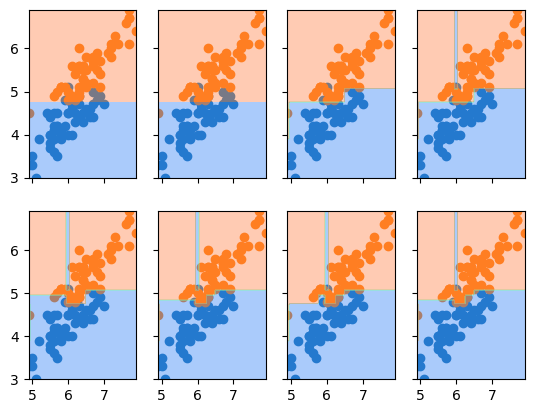

In [78]:
data_df = data[(data["species"] == 3) | (data["species"] == 2)] 

X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

data_df_seposa = data_df[data_df["species"] == 3] 
data_df_virginica = data_df[data_df["species"] == 2]

max_depth = [[1, 2, 3, 4], [5, 6, 7, 8]]

fig, ax = plt.subplots(2, 4, sharex='col', sharey='row')

for i in range(2):
    for j in range(4):
        ax[i, j].scatter(data_df_virginica["sepal_length"], data_df_virginica["petal_length"]) 
        ax[i, j].scatter(data_df_versicolor["sepal_length"], data_df_versicolor["petal_length"])

        model = DecisionTreeClassifier(max_depth=max_depth[i][j])
        model.fit(X, y)

        x1_p = np.linspace (min(data_df["sepal_length"]), max(data_df["sepal_length"]), 100) 
        x2_p = np.linspace (min(data_df["petal_length"]), max(data_df["petal_length"]), 100)

        X1_p, X2_p = np.meshgrid(x1_p, x2_p)

        X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=["sepal_length", "petal_length"])

        
        y_p = model.predict(X_p)

        ax[i, j].contourf(
            X1_p, X2_p, y_p.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1
        )



plt.show()